In [3]:
import pandas as pd

# Load full quantum features
df_syn = pd.read_csv("mci/mci_features_quantum.csv")

df_sn = pd.read_csv("stroke/stroke_features_quantum.csv")

df_pd = pd.read_csv("parkinson/quantum_raw_parkinsons_gait_percent.csv")

In [8]:
X_syn = df_syn.drop(columns=["Label"])
X_sn = df_sn.drop(columns=["Label"])
X_pd = df_pd.drop(columns=["Subject_ID","label"])


In [9]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Suppose X_syn, X_sn, X_pd are your flattened feature matrices (one frame per row, features per column)
datasets = {
    "Syn-MCI": X_syn,
    "SN-Gait": X_sn,
    "PD-Gait": X_pd
}

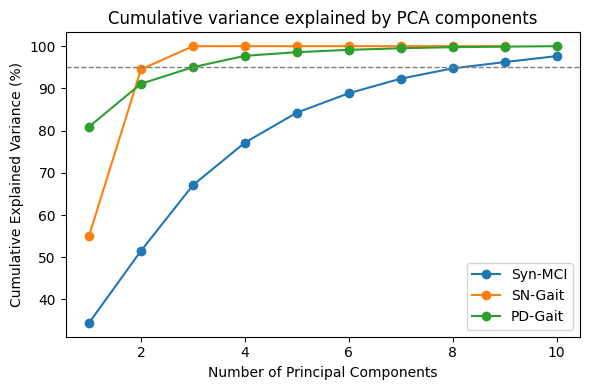

In [12]:
plt.figure(figsize=(6,4))
for name, X in datasets.items():
    pca = PCA(n_components=min(10, X.shape[1]))
    pca.fit(X)
    cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
    plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', label=name)

plt.axhline(95, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative variance explained by PCA components")
plt.legend()
plt.tight_layout()
plt.savefig("Fig3b_pca_variance.png", dpi=300)
plt.show()